# BE 521: Homework 1 Questions

Spring 2022

33 points

Due: January 26th 2022

Objective: Working with the IEEG Portal to explore different Neural Signals.

## 1. Seizure Activity (16 pts)

The dataset I521_A0001_D002 contains an example of human intracranial EEG (iEEG) data displaying seizure activity. It is recorded from a single channel (2 electrode contacts) implanted in the hippocampus of a patient with temporal lobe epilepsy being evaluated for surgery. In these patients, brain tissue where
seizures are seen is often resected. You will do multiple comparisons with this iEEG data and the unit activity that you worked with in Homework 0 (I521_A0001_D001). You will have to refer to that homework and/or dataset for these questions.

In [ ]:
#Set up the notebook environment
!pip install git+https://github.com/ieeg-portal/ieegpy.git # Install ieegpy toolbox directly from github
from ieeg.auth import Session
from IPython.display import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig

  Cloning https://github.com/ieeg-portal/ieegpy.git to /tmp/pip-req-build-fulyyq_i
  Running command git clone -q https://github.com/ieeg-portal/ieegpy.git /tmp/pip-req-build-fulyyq_i
     |████████████████████████████████| 98 kB 3.5 MB/s 
  Created wheel for ieeg: filename=ieeg-1.6-py3-none-any.whl size=27518 sha256=3b49b7688dbc0ee49d1f218505bbf550325ce247bfef661f453676d1dc885635
  Stored in directory: /tmp/pip-ephem-wheel-cache-i03ue83i/wheels/fc/25/6b/f0abef98e42210733b10da832632e70364eb24abf17ca19d0d
Successfully built ieeg


### 1
Retrieve the dataset using the IEEGToolbox and generate a session variable as before (nno need to report the output this time). What is the sampling rate of this data? What is the maximum frequency of the signal content that we can resolve? (2 pts)

In [ ]:
#open dataset
with open("qaq_ieeglogin.bin","r") as f:
  pwd = f.read();
session = Session('qaq233tvt',pwd)
dataset = session.open_dataset('I521_A0001_D002')
#Retrieving time series information
for name in dataset.get_channel_labels():
  timeSeries = dataset.get_time_series_details(name)
print('Sampling Rate of the data is %.1f Hz.'%timeSeries.sample_rate)

Sampling Rate of the data is 200.0 Hz.


The sampling rate is 200.0Hz. 

According to the Nyquist Theorem, the maximum frequency of the signal content we can resolve would be half of the sampling rate, so that at least two samples per signal is ensured[\[1\]](https://en.wikipedia.org/wiki/Nyquist–Shannon_sampling_theorem). Hence, in this case, we can resolve at most signal content of 100.0Hz.

### 2
How does the duration of this recording compare with the recording from HW0  (I521_A0001_D001)? (2 pts)

In [ ]:
print('Duration of this recording is %.3f seconds.'%(timeSeries.duration/1e6))

Duration of this recording is 644.995 seconds.


Duration of this recording is 644.995 seconds, much longer than that of HW0, which is 10.0 seconds.

### 3
Using the time-series visualization functionality of the IEEG Portal, provide a plot of the first 500 ms of data from this recording. (2 pts)

Screenshot obtained through IEEG Portal is shown below.

### 4
Compare the activity in this sample with the data from HW0. What differences do you notice in the amplitude and frequency characteristics? (2 pts)

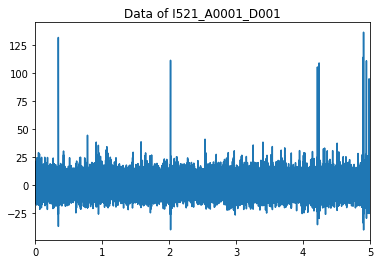

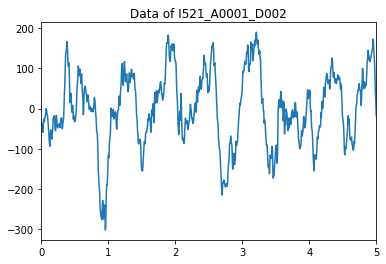

In [ ]:
def plotsampledata(dataname):
  #open dataset and time series information
  dataset = session.open_dataset(dataname)
  for name in dataset.get_channel_labels():
    timeSeries = dataset.get_time_series_details(name)
  sampling_rate = timeSeries.sample_rate
  #obtaining data for first 5 secs
  data = dataset.get_data(0, 5*1e6+1, dataset.get_channel_indices(dataset.get_channel_labels()))
  #plot
  time = np.linspace(0,5,len(data))
  plt.plot(time, data)
  plt.xlim([0,5])
  plt.title('Data of %s'%dataname)
  plt.show()


plotsampledata('I521_A0001_D001')
plotsampledata('I521_A0001_D002')

In [ ]:
print(timeSeries)

None(seizure) spans 644995000.0 usec, range [-2216-2221] in 129000 samples. Starts @1 uUTC, ends @644995001 uUTC with sample rate 200.0 Hz and voltage conv factor 1.0


Two figures showing the first 5 seconds of each dataset are displayed above. The timeseries information of this dataset is,

'None(seizure) spans 644995000.0 usec, range [-2216-2221] in 129000 samples. Starts @1 uUTC, ends @644995001 uUTC with sample rate 200.0 Hz and voltage conv factor 1.0'

While that of Hw0 being,

'None(units) spans 10000000.0 usec, range [-40229-136573] in 320511 samples. Starts @1 uUTC, ends @10000001 uUTC with sample rate 32051.0 Hz and voltage conv factor 0.001'

The frequency of this dataset is much lower compared with the data from Hw0. Loss of higher frequency portion in this dataset could be observed from the less compact and more smooth waveform, while loss of lower frequency portion could be observed from the lack of fluctuations for Hw0 data. Also, a sample rate difference in time series information exerts limit on frequency range.

The amplitude of this data is, however, larger thant that of Hw0. From observation, the Hw0 data is largely restricted to -25\~25 microvolts except for spikes, while this dataset shows larger fluctuations to hundreds of microvolts. Also, the maximum values shown in the timeseries information differ a lot (\~2000 for Hw1 versus \~130 for Hw0). 

### 5
The unit activity sample in (I521_A0001_D001) was high-pass filtered to remove low-frequency content. Assume that the seizure activity in (I521_A0001_D002) has not been high-pass filtered. Given that the power of a frequency band scales roughly as $1/f$, how might these dierences in preprocessing contribute to the differences you noted in the previous question? (There is no need to get into specific calculations here. We just want general ideas.) (3 pts)

Given the power characteristics, the lower the frequence, the higher the power of a frequency band. After high-pass, the lower frequency and higher power portion of the data is excluded from the data in Hw0. As power also positively correlated with amplitude of certain frequency, this may lead to a drop in overall amplitude for Hw0 dataset and loss of lower frequency fluctuations. 

However, the low sampling rate of this Hw1 dataset may account for more of the lost of higher frequency and the much smoother curve observed for this data.

### 6
Two common methods of human iEEG are known as electrocorticography (ECoG) and stereoelectroencephalography (SEEG). For either of these paradigms (please indicate which you choose), find and report at least two of the following electrode characteristics: shape, material, size. Please note that exact numbers aren't required, and please cite any sources used. (3 pts)

sEEG intracranial electrodes are long and thin, thus may penetrate deeply into the brain to better localize seizure positions[\[2\]](https://doi.org/10.1016/B978-0-12-805353-9.00027-9). It normally has a diameter of about 1 mm, or even 0.8 mm for many current products[\[3\]](https://diximedus.com)[\[4\]](http://www.pmtcorp.com/seeg.html). The length of the electrode would be varied, but at the order of centimeters, consisting of 4-20 contacts made of platinum/iridium, which are normally 2 mm each in length and millimeters(for instance, 1.5 mm for Dixi products) apart[\[3\]](https://diximedus.com)[\[4\]](http://www.pmtcorp.com/seeg.html)[\[5\]](https://doi.org/10.3389/fnins.2020.00123). 

Electrodes of ECoG are generally strip or grid electrodes covering large area of the cortex. Single electrodes are normally made of platinum/iridium, ~4 mm in diameter and ~2 mm for contact opening. Electrodes would then be embedded in silicon sheet at distance of approximately 10 mm to form grids or strips. Grides may have various sizes, with 8X8 electrodes being the most common design, while strips typically have 4/6/8 electrodes in one line.[\[6\]](https://dx.doi.org/10.3791%2F3993)[\[7\]](https://www.gtec.at/product/cortiq-ecog-electrodes/)

### 7
What is a local field potential? How might the characteristics of human iEEG electrodes cause them to record local field potentials as opposed to multiunit activity, which was the signal featured in HW0 as recorded from 40 micron Pt-Ir microwire electrodes? (2 pts)

Local field potential is the summed electrical flucations of nearby neurons and other possible contributors, measured by electrodes at a certain extracellular space. 

The above mentioned iEEG electrodes all have much larger diameters and contact areas compared with the 40 micron microwire electrodes for multiunit activity recording. According to Vijay et al.[\[8\]](https://doi.org/10.3389/fnins.2019.00385), the electrode size may determine the charge amount detected - larger electrodes correspond to larger area, yet higher averaging effects in the meantime. The recorded signal would be averaged, thus making detailed events such as spikes decrease in amplitude and hard to detect.


## 2. Evoked Potentials (17 pts)

The data in I521 A0001 D003 contains an example of a very common type of experiment and neuronal signal, the evoked potential (EP). The data show the response of the whisker barrel cortex region of rat brain to an air puff stimulation of the whiskers. The stim channel shows the stimulation pattern, where the falling edge of the stimulus indicates the start of the air puff, and the rising edge indicates the end. The ep channel shows the corresponding evoked potential. Once again, play around with the data on the IEEG Portal, in particular paying attention to the effects of stimulation on EPs. You should observe the data with window widths of 60 secs as well as 1 sec. Again, be sure to explore the signal gain to get a more accurate picture. Finally, get a sense for how long the trials are (a constant duration), and how long the entire set of stimuli and responses are.

### 1 
Based on your observations, should we use all of the data or omit some of it? (There's no right answer, here, just make your case either way in a few sentences.) (2 pts)

I believe two trials start at time point 46s and 47s could be omitted in this case.

Normally, trials with errors due to the experimenter, such as inconsistent stimulation, or is oberserved to have fluctuations surely affecting measurement should be excluded. 

In this case, no obvious inconsistency in stim has been observed. For the signal recorded, the amplitude are generally consistent, despite fluctuated baseline which should be acceptable brainwave oscillations. The waveform of most trials are similar. However, in some cases, such as the 6-second session starting from 44 seconds(shown above), a unique abrupt multi-peak waveform has been observed. It is not sure whether such irregular trials are artifacts or are natural phenomenon. 

Generally, recordings or other sources available for this session should be re-examined to identify any possible influences or abnormalities. Other examination against known artifact situations could also be done. If observed, this portion could be rejected.

Here, I prefer to reject only two trials at time point 46s and 47s, given that the signal are at peak instead of resting baseline when the stimulus is exerted. Such irregular initial situation may cause following response abnormal. Other trials remain normal during the stim and the waveform afterward may reflect special situations worth analyzing. Hence, these trials could be kept for further analysis and should not be omitted at first place.


### 2
Retrieve the ep and stim channel data in Colab. What is the average latency (in ms) of the peak response to the stimulus onset over all trials? (Assume stimuli occurs at exactly 1 second intervals.) (3 pts)

In [ ]:
def peakFinding(data,thres):  
  #setting threshold and spike distance
  thresCalc = np.mean(data)+thres*np.std(data)
  #smoothing data
  win = 39
  dataSmooth = np.convolve(data, np.ones(win), 'valid') / win
  #finding local maxima
  maxima = sig.argrelextrema(dataSmooth, np.greater)
  #finding first maxima exceeding threshold
  peak = 0
  for i in maxima[0]:
    if data[i] >= thresCalc:
      peak = i
      break
  return peak+int((win-1)/2) #fixing the index shift due to smoothing

In [ ]:
#open dataset
datasetEP = session.open_dataset('I521_A0001_D003')
labelEP = datasetEP.get_channel_labels()

#obtaining time series information
timeSeriesEP = datasetEP.get_time_series_details(labelEP[0])

#obtaining data
dataEP = datasetEP.get_data(0, timeSeriesEP.duration+1, datasetEP.get_channel_indices(labelEP))

#splitting data into trials of 1 sec length and do rejection
dataEP_trial = np.reshape(dataEP[:,0],(-1,int(timeSeriesEP.sample_rate)))
dataEP_trial = np.delete(dataEP_trial,[46,47],axis = 0)

#finding peak for each trial
peak = []
for i in range(np.size(dataEP_trial,0)):
  tmp = peakFinding(dataEP_trial[i,:],1.2)
  peak.append(tmp)

#calculating average latency
avgLatFrame = np.mean(peak)
avgLat = avgLatFrame/timeSeriesEP.sample_rate*1e3
print('The average latency is %.2f ms.'%avgLat)

The average latency is 134.30 ms.


The average latency is 134.30 ms.

### 3
In neuroscience, we often need to isolate a small neural signal buried under an appreciable amount of noise. One technique to accomplish this is called the "spike triggered average", sometimes called "signal averaging". This technique assumes that the neural response to a repetitive stimulus is constant (or nearly so), while the noise fluctuates from trial to trial - therefore averaging the evoked response over many trials will isolate the signal and average out the noise. Construct a spike triggered average plot for the data in I521 A0001 D003. Plot the average EP in red. Overlay the standard deviation of the responses in grey. 
You may find [`plt.fill_between`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.fill_between.html) and [`np.linspace`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) to be helpful. Be sure to include an informative legend. You may also find [this](https://matplotlib.org/stable/gallery/color/named_colors.html) to be helpful for what colors plyplot natively supports (4 pts).

First, the data is averaged within each trial by subtracting the mean of this trial. This step is done to correct for the baseline shift across trials.

Then, average and standard deviation of all trails are calculated and plotted.

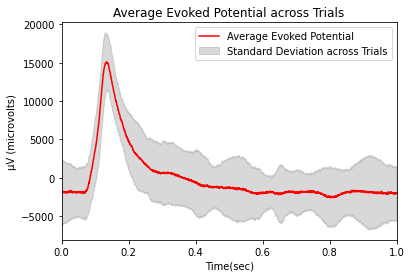

In [ ]:
#average within trial, given differed baseline
dataEP_trial_baserm = []
for i in range(np.size(dataEP_trial,axis = 0)):
  dataEP_trial_baserm.append(dataEP_trial[i,:]-np.mean(dataEP_trial[i,:]))
dataEP_trial_baserm = np.reshape(dataEP_trial_baserm,(-1,int(timeSeriesEP.sample_rate)))

#average across trial
avgTrial = np.mean(dataEP_trial_baserm,axis = 0)
stdTrial = np.std(dataEP_trial_baserm,axis = 0)

#plot setting
domain = np.linspace(0, 1,num=int(timeSeriesEP.sample_rate))
plt.fill_between(domain,avgTrial+stdTrial,avgTrial-stdTrial,color='grey',alpha = 0.3,label = 'Standard Deviation across Trials')
plt.plot(domain,avgTrial,'r',label='Average Evoked Potential')
plt.title('Average Evoked Potential across Trials')
plt.xlabel('Time(sec)')
plt.ylabel('μV (microvolts)')
plt.xlim([0, 1])
plt.legend(loc='upper right')
plt.show()


### 4. 

####4a
We often want to get a sense for the amplitude of the noise in a single trial. Propose a method to do this (there are a few reasonably simple methods, so no need to get too complicated). Note: do not assume that the signal averaged EP is the "true" signal and just subtract it from that of each
trial, because whatever method you propose should be able to work on the signal from a single trial or from the average of the trials. (4 pts)

Substracting smoothed curve could be a potential way to estimate noise.

Assume within a certain short time range, the change of the true signal are relative small, while noise fluctuate. Hence, averaging within this small time range may cancel the noise.

A function and the results of an example trial are shown below. The function extracts a noise of consistent amplitude and fit in gaussian distribution.

In [ ]:
def noiseEstimate(trial):
  #This function calculates estimated noise signal through subtracting smoothed signal, and return the noise-removed signal and noise respectively.
  #calculate smoothed curve
  win = 15
  trialSmooth = np.convolve(trial, np.ones(win), 'valid') / win
  #fill to original size with two end values
  trialSmooth = np.concatenate(([trial[0] for number in range(int((win-1)/2))],trialSmooth,[trial[-1] for number in range(int((win-1)/2))]))
  #split noise through subtraction
  noise = trial-trialSmooth
  return (trialSmooth, noise)

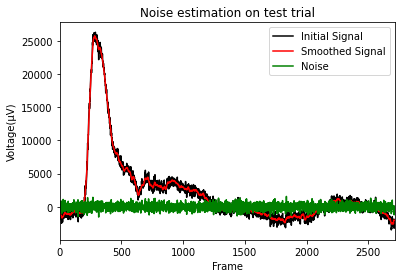

In [ ]:
#estimate noise
smoothExp,noiseExp = noiseEstimate(dataEP_trial[0,:])
#plot de-noised data and noise
plt.plot(dataEP_trial[0,:],'black',label='Initial Signal')
plt.plot(smoothExp,'r',label = 'Smoothed Signal')
plt.plot(noiseExp,'g',label = 'Noise')
plt.legend(loc='upper right')
plt.ylabel('Voltage(µV)')
plt.xlabel('Frame')
plt.title('Noise estimation on test trial')
plt.xlim([0,timeSeriesEP.sample_rate])
plt.show()

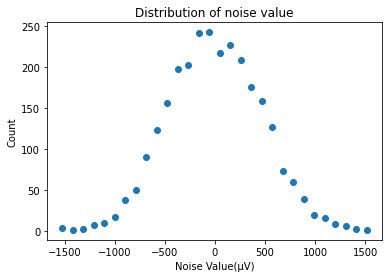

In [ ]:
#plot statistics of noise values
count,bin,tmp = plt.hist(noiseExp,30,histtype='step')
plt.close()
bin_mean = [0.5 * (bin[i] + bin[i+1]) for i in range(len(count))]
plt.scatter(bin_mean,count)
plt.title('Distribution of noise value')
plt.ylabel('Count')
plt.xlabel('Noise Value(µV)')
plt.show()

#### 4b
Show with a few of the EPs (plots and/or otherwise) that your method gives reasonable results. You may find [`sig.butter`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html) and [`sig.filtfilt`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.filtfilt.html) helpful. (1 pt)

It could be assumed that noise are higher frequency fluctuating signals, while the true data are low frequency wave. It would then be possible to separate bandlimited signals from broad band noise through frequency filters. Below a noise splitter is defined through separating data lower than and higher than a certain frequency threshold respectively. The lowpassed data would be considered as data while the highpassed portion be considered as noise. 

Given the response with regard to the stimulus would be the true signal, and the waveform already observed, the frequency of true signal should not be too high. Here, 100 Hz is adopted as the threshold, which could be adjusted through other established methods such as machine learning. Despite the noise filtered out here would not be the exact noise signal, the noise amplitude level would be similar, given the 1/f principle mentioned above. Besides, the estimate method proposed above could also be adjusted accordingly through varied smooth window size.

In [ ]:
def noiseSplitter(data,thres):
  #This function split the signal to data below and higher than certain threshold
  #Define filters
  bl,al = sig.butter(8,thres)
  bh,ah = sig.butter(8,thres,btype='high')
  #Filtering data
  dataLow = sig.filtfilt(bl,al,data)
  dataHigh = sig.filtfilt(bh,ah,data)
  return dataLow,dataHigh

def compNoise(data,ind):
  #This function adopts the proposed noise estimation and the noise filtering methods and compare their results
  #Calculate Noise
  data1,noise1 = noiseEstimate(data)
  data2,noise2 = noiseSplitter(data,0.1)
  #Plotting Results
  domain = np.linspace(0, 1,num=int(timeSeriesEP.sample_rate))
  fig, ax = plt.subplots(2)
  fig.suptitle('Noise Comparison of Trial %d'%ind)
  ax[0].plot(domain,data,'grey',label='Initial Signal')
  ax[0].plot(domain,data1,'b',label = 'Estimated Signal')
  ax[0].plot(domain,data2,'g',label = 'Filtered Signal')
  ax[0].legend(loc='upper right')
  ax[0].set_xlim([0,1])
  ax[0].set_ylabel('Voltage(µV)')
  ax[1].plot(domain,noise1,'b',label = 'Estimated Noise')
  ax[1].plot(domain,noise2,'g',label = 'Filtered Noise')
  ax[1].legend(loc='upper right')
  ax[1].set_xlim([0,1])
  ax[1].set_ylabel('Voltage(µV)')
  ax[1].set_xlabel('Time(sec)')

It could be noticed that in below cases, the estimated noise is largely consistent with the filtered noise, while the results correlation between two methods is 0.9685, approaching 1. This cross validation may suggest reasonable results. 

The correlation of noise amplitude between two methods are 0.9685.


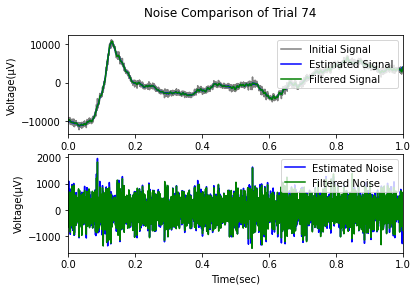

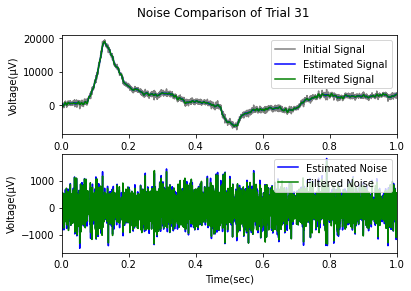

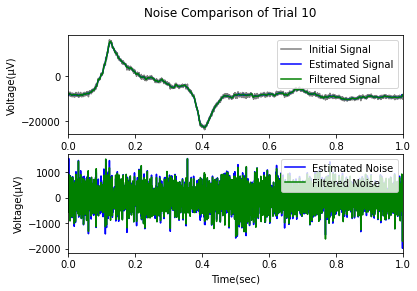

In [ ]:
#Randomly choosing 3 trials for test
randInd = np.random.randint(0,np.size(dataEP_trial,0),3)
for i in range(len(randInd)):
  compNoise(dataEP_trial[randInd[i],:],randInd[i])

noise1 = [];noise2 = []
for i in range(np.size(dataEP_trial,0)):
  tmp1,tmp2 = noiseEstimate(dataEP_trial[i,:])
  noise1.append(np.mean(abs(tmp2)))
  tmp1,tmp2 = noiseSplitter(dataEP_trial[i,:],0.1)
  noise2.append(np.mean(abs(tmp2)))
print('The correlation of noise amplitude between two methods are %.4f.'%np.corrcoef(noise1, noise2)[1,0])

#### 4c
Apply your method on each individual trial and report the mean noise amplitude across all trials. (1 pt)

The mean noise amplitude across all trials is 363.00 µV.


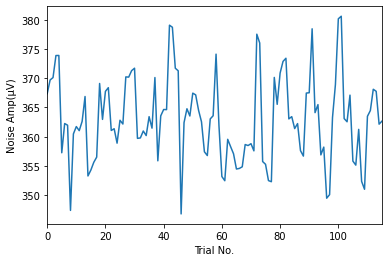

In [ ]:
#store noise amplitude of each trial
noiseAmp = []
#calculate mean noise amplitude of each trial
for i in range(np.size(dataEP_trial_baserm,0)):
  tmp,noise = noiseEstimate(dataEP_trial_baserm[i,:])
  noiseAmp.append(np.mean(abs(noise)))
#plot noise of all trials
plt.plot(noiseAmp,label = 'Noise Amplitude')
plt.xlabel('Trial No.')
plt.ylabel('Noise Amp(µV)')
plt.xlim([0,np.size(dataEP_trial,0)-1])
#calculate mean across all trials
print('The mean noise amplitude across all trials is %.2f µV.'%np.mean(noiseAmp))

The noise of all trials are ploted above, the mean of all trials are calculated to be 363 µV.

#### 4d
Apply your method on the signal averaged EP and report its noise. (1 pt)

The mean noise amplitude of the averaged EP is 37.87 µV.


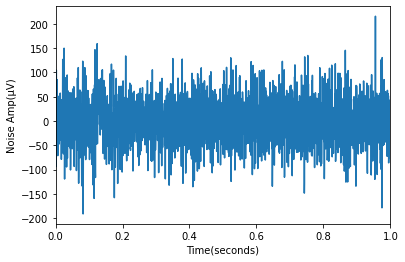

In [ ]:
#calculate noise of averaged EP
tmp,noiseAmpAvg = noiseEstimate(avgTrial)
#plot
plt.plot(domain,noiseAmpAvg,label = 'Noise Amplitude of Averaged EP')
plt.xlabel('Time(seconds)')
plt.ylabel('Noise Amp(µV)')
plt.xlim([0,1])
#calculate mean
print('The mean noise amplitude of the averaged EP is %.2f µV.'%np.mean(abs(noiseAmpAvg)))

The mean noise amplitude of the averaged EP is 37.87 µV.

#### 4e
Do these two values make sense? Explain. (1 pt)

The first value is 363.00µV, calculated as the mean noise amplitude of noise of each trial. The second value is the noise amplitude of averaged trials, which is 37.87µV.

The values makes sense. During trial averaging, the noise signal are largely canceled due to its random nature, while the buried true signal are theoretically consistent and remained unchanged. Hence, noise amplitude calculated before averaging would be significantly larger than that after averaging. 